# Text Flappy Bird RL Assignment

**Name:** Supriya Malla

This notebook implements and compares two tabular reinforcement learning agents on the simple `TextFlappyBird-v0` environment:

- first-visit Monte Carlo control with an epsilon-greedy policy,
- Sarsa($\lambda$) with eligibility traces.

I focus on the simple distance-based observation space because it is the most natural setting for tabular methods.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

project_root = Path.cwd()
if project_root.name == "rl_assignment":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from rl_assignment import (
    EnvConfig,
    MonteCarloControlAgent,
    SarsaLambdaAgent,
    TrainingConfig,
    run_parameter_sweep,
    train_agent,
    transfer_evaluation,
)
from rl_assignment.experiments import make_env
from rl_assignment.plotting import (
    plot_parameter_sweep,
    plot_training_history,
    plot_value_heatmaps,
)


## 1. Environment Sanity Check

The simple environment returns a 2D state `(dx, dy)`:

- `dx`: horizontal distance to the next pipe gap,
- `dy`: vertical distance between the bird and the center of that gap.

This is much easier to study with tabular RL than the screen-render environment.

In [2]:
env_config = EnvConfig(height=15, width=20, pipe_gap=4)
env = make_env(env_config)
obs, info = env.reset()
print("Initial observation:", obs)
print("Initial info:", info)
print(env.render())
env.close()


Initial observation: (13, -4)
Initial info: {'score': 0, 'player': [6, 7], 'distance': 13.601470508735444}
Text Flappy Bird!
Score: 0
----------------------
[                   |]
[                   |]
[                   |]
[                   |]
[                   |]
[                   |]
[                   |]
[      @            |]
[                   |]
[                    ]
[                    ]
[                    ]
[                    ]
[                   |]
[                   |]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Idle)
Distance From Pipe (dx=13,dy=-4)



## 2. Baseline Training Setup

I use the same environment and training horizon for both agents so the comparison stays fair. The baseline setting below is also the one used to generate the saved CSV/PNG files in `rl_assignment/results/`.

In [3]:
baseline_training = TrainingConfig(
    episodes=2000,
    max_steps=200,
    eval_every=200,
    eval_episodes=30,
)

mc_agent = MonteCarloControlAgent(
    gamma=0.99,
    epsilon=0.20,
    epsilon_decay=0.999,
    min_epsilon=0.01,
    seed=1,
)

sarsa_agent = SarsaLambdaAgent(
    alpha=0.15,
    lambda_=0.9,
    gamma=0.99,
    epsilon=0.10,
    epsilon_decay=0.999,
    min_epsilon=0.02,
    seed=2,
)


## 3. Monte Carlo Control

In [4]:
mc_history, mc_eval = train_agent(
    mc_agent,
    env_config=env_config,
    training_config=baseline_training,
    seed=42,
)
display(mc_eval)


,episode,mean_eval_return,std_eval_return,mean_eval_score,std_eval_score
0,200,57.033333,47.170247,4.833333,4.691008
1,400,87.366667,52.457909,7.866667,5.245527
2,600,156.133333,62.743251,14.700000,6.165225
3,800,149.566667,63.906538,14.066667,6.255309
4,1000,157.500000,60.915652,14.800000,5.957628
5,1200,138.366667,70.839482,12.866667,7.069811
6,1400,156.166667,56.568002,14.666667,5.575741
7,1600,151.533333,56.694934,14.300000,5.568662
8,1800,151.966667,71.161077,14.266667,7.061319
9,2000,168.700000,46.293376,16.000000,4.546061


(<Figure size 1500x400 with 6 Axes>,
 array([<Axes: title={'center': 'Q(s, idle)'}, xlabel='dx', ylabel='dy'>,
        <Axes: title={'center': 'Q(s, flap)'}, xlabel='dx', ylabel='dy'>,
        <Axes: title={'center': 'V(s)'}, xlabel='dx', ylabel='dy'>],
       dtype=object))

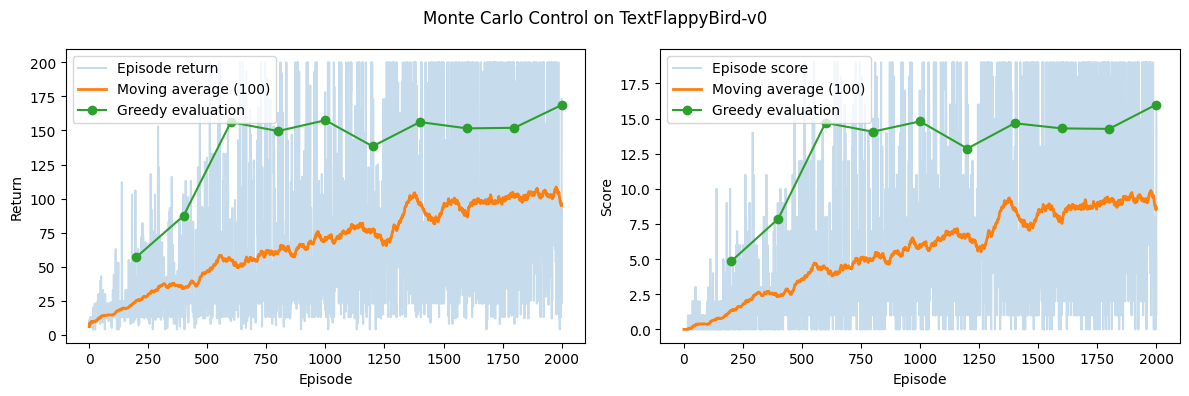

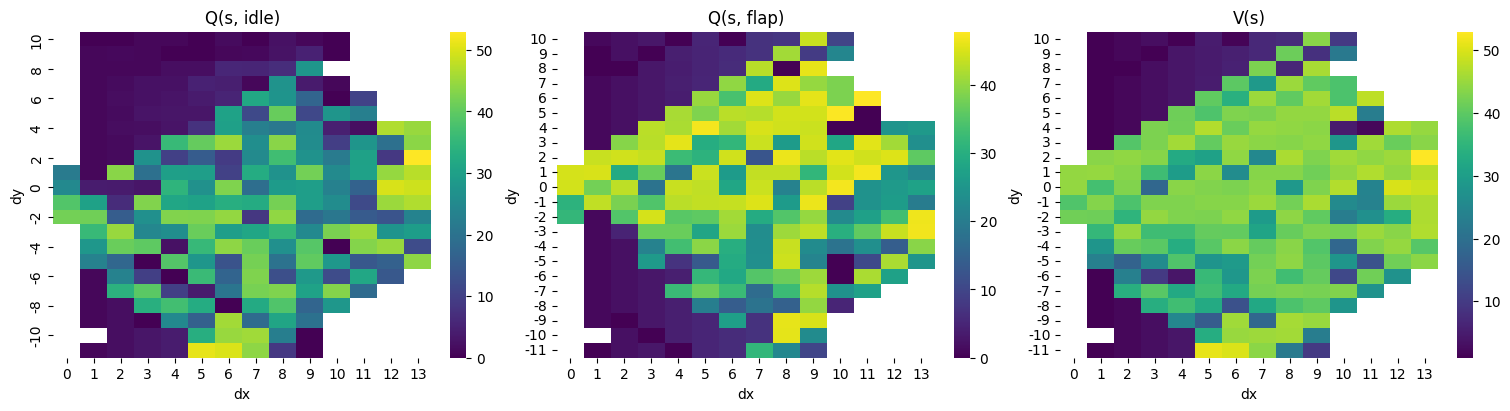

In [5]:
plot_training_history(
    mc_history,
    mc_eval,
    window=baseline_training.moving_average_window,
    title="Monte Carlo Control on TextFlappyBird-v0",
)
plot_value_heatmaps(mc_agent, env_config)


## 4. Sarsa($\lambda$)

In [6]:
sarsa_history, sarsa_eval = train_agent(
    sarsa_agent,
    env_config=env_config,
    training_config=baseline_training,
    seed=84,
)
display(sarsa_eval)


,episode,mean_eval_return,std_eval_return,mean_eval_score,std_eval_score
0,200,11.000000,3.376389,0.033333,0.179505
1,400,12.766667,5.475298,0.200000,0.541603
2,600,19.500000,11.497101,0.800000,1.166190
3,800,36.233333,13.383281,2.533333,1.334999
4,1000,68.466667,51.112773,5.633333,5.082541
5,1200,119.500000,57.237954,11.066667,5.644663
6,1400,133.900000,56.989677,12.533333,5.631657
7,1600,152.033333,60.926449,14.266667,6.071427
8,1800,168.300000,52.990031,15.833333,5.285725
9,2000,175.066667,52.947101,16.500000,5.333854


(<Figure size 1500x400 with 6 Axes>,
 array([<Axes: title={'center': 'Q(s, idle)'}, xlabel='dx', ylabel='dy'>,
        <Axes: title={'center': 'Q(s, flap)'}, xlabel='dx', ylabel='dy'>,
        <Axes: title={'center': 'V(s)'}, xlabel='dx', ylabel='dy'>],
       dtype=object))

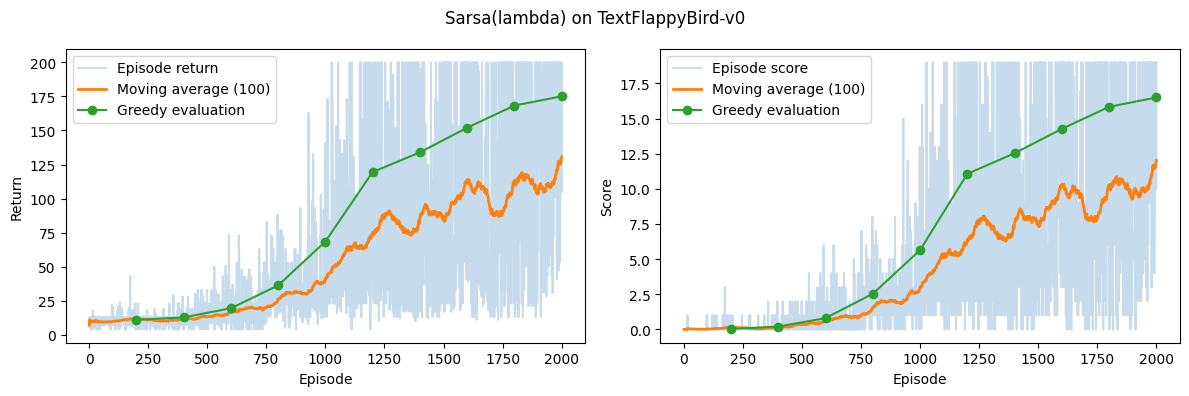

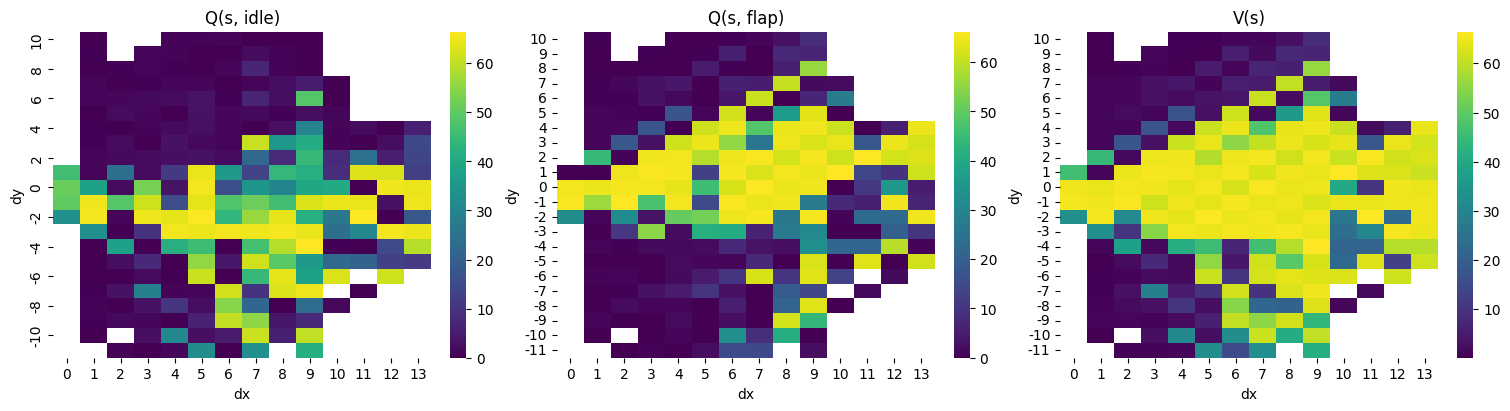

In [7]:
plot_training_history(
    sarsa_history,
    sarsa_eval,
    window=baseline_training.moving_average_window,
    title="Sarsa(lambda) on TextFlappyBird-v0",
)
plot_value_heatmaps(sarsa_agent, env_config)


## 5. Small Parameter Sweeps

I kept the sweeps small and focused so they stay easy to interpret. The goal is not exhaustive search, but to show sensitivity to a few important hyperparameters.

,label,mean_eval_return,mean_eval_score
0,"gamma=0.99, epsilon=0.05, epsilon_decay=0.999,...",160.35,14.95
1,"gamma=0.99, epsilon=0.1, epsilon_decay=0.999, ...",162.05,15.10
2,"gamma=0.99, epsilon=0.2, epsilon_decay=0.999, ...",175.40,16.55


,label,mean_eval_return,mean_eval_score
0,"alpha=0.05, lambda_=0.7, gamma=0.99, epsilon=0...",9.8,0.00
1,"alpha=0.1, lambda_=0.8, gamma=0.99, epsilon=0....",17.2,0.65
2,"alpha=0.15, lambda_=0.9, gamma=0.99, epsilon=0...",130.8,12.00


/Users/supriyamalla/Documents/centrale/deep-learning-2-labs/session3/rl_assignment/plotting.py:125: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Sarsa(lambda) Parameter Sweep'}, xlabel='Setting', ylabel='Mean Eval Return'>)

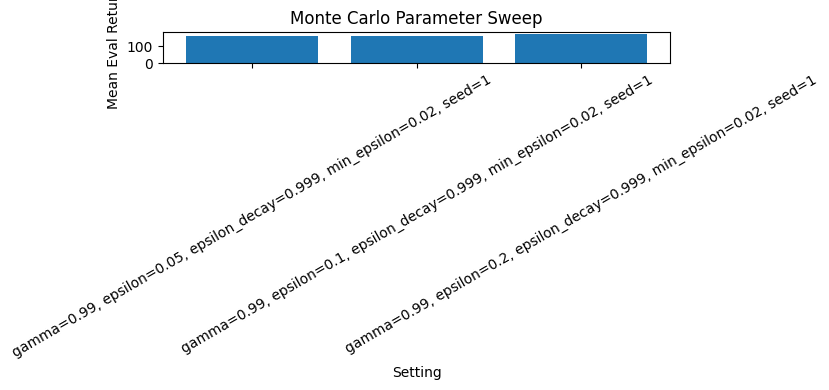

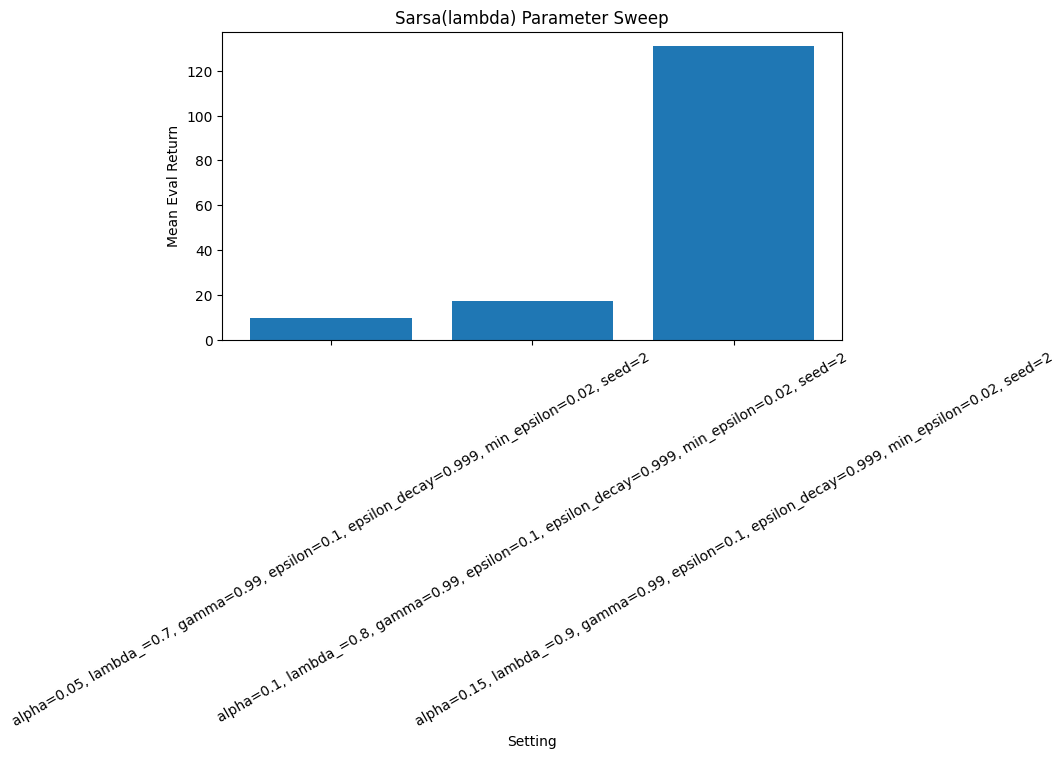

In [8]:
sweep_training = TrainingConfig(
    episodes=800,
    max_steps=200,
    eval_every=100,
    eval_episodes=20,
)

mc_sweep_values = [
    {"gamma": 0.99, "epsilon": 0.05, "epsilon_decay": 0.999, "min_epsilon": 0.02, "seed": 1},
    {"gamma": 0.99, "epsilon": 0.10, "epsilon_decay": 0.999, "min_epsilon": 0.02, "seed": 1},
    {"gamma": 0.99, "epsilon": 0.20, "epsilon_decay": 0.999, "min_epsilon": 0.02, "seed": 1},
]

sarsa_sweep_values = [
    {"alpha": 0.05, "lambda_": 0.7, "gamma": 0.99, "epsilon": 0.10, "epsilon_decay": 0.999, "min_epsilon": 0.02, "seed": 2},
    {"alpha": 0.10, "lambda_": 0.8, "gamma": 0.99, "epsilon": 0.10, "epsilon_decay": 0.999, "min_epsilon": 0.02, "seed": 2},
    {"alpha": 0.15, "lambda_": 0.9, "gamma": 0.99, "epsilon": 0.10, "epsilon_decay": 0.999, "min_epsilon": 0.02, "seed": 2},
]

mc_sweep, _ = run_parameter_sweep(
    MonteCarloControlAgent,
    mc_sweep_values,
    env_config=env_config,
    training_config=sweep_training,
    seed=10,
)
sarsa_sweep, _ = run_parameter_sweep(
    SarsaLambdaAgent,
    sarsa_sweep_values,
    env_config=env_config,
    training_config=sweep_training,
    seed=20,
)

display(mc_sweep)
display(sarsa_sweep)
plot_parameter_sweep(mc_sweep, title="Monte Carlo Parameter Sweep")
plot_parameter_sweep(sarsa_sweep, title="Sarsa(lambda) Parameter Sweep")


## 6. Transfer to Other Environment Configurations

To answer the generalization question from the assignment, I evaluate the agents on a few modified layouts after training on the default one.

In [9]:
transfer_configs = [
    EnvConfig(height=15, width=20, pipe_gap=4),
    EnvConfig(height=18, width=20, pipe_gap=4),
    EnvConfig(height=15, width=24, pipe_gap=4),
    EnvConfig(height=15, width=20, pipe_gap=5),
]

mc_transfer = transfer_evaluation(
    mc_agent,
    env_configs=transfer_configs,
    episodes=30,
    max_steps=200,
    seed=101,
)
sarsa_transfer = transfer_evaluation(
    sarsa_agent,
    env_configs=transfer_configs,
    episodes=30,
    max_steps=200,
    seed=202,
)

display(mc_transfer)
display(sarsa_transfer)


,environment,height,width,pipe_gap,mean_return,mean_score
0,"height=15, width=20, pipe_gap=4",15,20,4,156.533333,14.766667
1,"height=18, width=20, pipe_gap=4",18,20,4,108.200000,9.666667
2,"height=15, width=24, pipe_gap=4",15,24,4,78.566667,5.933333
3,"height=15, width=20, pipe_gap=5",15,20,5,181.200000,17.133333


,environment,height,width,pipe_gap,mean_return,mean_score
0,"height=15, width=20, pipe_gap=4",15,20,4,186.733333,17.733333
1,"height=18, width=20, pipe_gap=4",18,20,4,105.866667,9.500000
2,"height=15, width=24, pipe_gap=4",15,24,4,124.066667,9.566667
3,"height=15, width=20, pipe_gap=5",15,20,5,184.933333,17.500000


## 7. Draft Discussion Points

These are the main conclusions I would reuse in the report and then tighten into full paragraphs:

1. **Experimental setup.** Both agents were trained on the simple `TextFlappyBird-v0` environment with the same default level configuration `(height=15, width=20, pipe_gap=4)`. Performance was tracked with episode return and score.
2. **Difference between the agents.** In my runs, Monte Carlo improved faster early on and reached stronger performance sooner. Sarsa($\lambda$) improved more gradually but still learned a useful policy by the end of training.
3. **Difference between the two environment versions.** The simple environment is compact and tabular, while the screen environment is much higher-dimensional. The simple environment is easier for value-table methods, but it also throws away some visual information.
4. **Can the same agents be used on the original Flappy Bird gym?** Not directly in the RGB version. The state is too large for tabular lookup. For the simple original environment, a discretization step would still be needed because the observations are continuous.
5. **Transfer across level configurations.** Both agents transferred best to the easier case with a larger pipe gap. Performance dropped on taller and wider layouts, which suggests some overfitting to the training geometry.

A short report version of these points is enough as long as the figures and tables support them.

## Optional: Load the Saved Results Instead of Re-running Everything

If you already ran `python rl_assignment/run_experiments.py`, you can load the saved CSVs from `rl_assignment/results/` and avoid retraining when polishing the notebook.

In [10]:
results_dir = project_root / "rl_assignment" / "results"
saved_mc_eval = pd.read_csv(results_dir / "mc_eval.csv")
saved_sarsa_eval = pd.read_csv(results_dir / "sarsa_eval.csv")
saved_mc_transfer = pd.read_csv(results_dir / "mc_transfer.csv")
saved_sarsa_transfer = pd.read_csv(results_dir / "sarsa_transfer.csv")

display(saved_mc_eval.tail(1))
display(saved_sarsa_eval.tail(1))
display(saved_mc_transfer)
display(saved_sarsa_transfer)


,episode,mean_eval_return,std_eval_return,mean_eval_score,std_eval_score
9,2000,168.7,46.293376,16.0,4.546061


,episode,mean_eval_return,std_eval_return,mean_eval_score,std_eval_score
9,2000,175.066667,52.947101,16.5,5.333854


,environment,height,width,pipe_gap,mean_return,mean_score
0,"height=15, width=20, pipe_gap=4",15,20,4,156.533333,14.766667
1,"height=18, width=20, pipe_gap=4",18,20,4,108.200000,9.666667
2,"height=15, width=24, pipe_gap=4",15,24,4,78.566667,5.933333
3,"height=15, width=20, pipe_gap=5",15,20,5,181.200000,17.133333


,environment,height,width,pipe_gap,mean_return,mean_score
0,"height=15, width=20, pipe_gap=4",15,20,4,186.733333,17.733333
1,"height=18, width=20, pipe_gap=4",18,20,4,105.866667,9.500000
2,"height=15, width=24, pipe_gap=4",15,24,4,124.066667,9.566667
3,"height=15, width=20, pipe_gap=5",15,20,5,184.933333,17.500000
